# <div align="center"><u>Project 11 - Version 1</u>
    
- The following analysis focuses on the binary classification of healthy individuals versus cancer patients. The specific pathology addressed is Pancreatic Ductal Adenocarcinoma (PDAC), which accounts for approximately 90% of all pancreatic cancer cases. Due to the asymptomatic nature of its early stages, early detection remains a significant hurdle. Consequently, it is a high-priority challenge for researchers to develop machine learning algorithms and diagnostic solutions capable of identifying the disease in its infancy.
    
- The dataset utilized in this study consists of synthetic data, generated to reflect real-world clinical distributions. Each record adheres to established medical parameters and biological constraints observed in Pancreatic Ductal Adenocarcinoma (PDAC) patients and healthy controls:
    
    - Well-established bioindicators:
        - CA19-9, 12.5(±8.0) for healthy, 450(±210) for cancer, primary pancreatic rumor marker.
        - CEA, 1.8(±1.2) for healthy, 8.5(±5.5) for cancer, general marker for GI tract cancer.
        - Bilirubin(Total), 0.6(±0.3) for healthy, 2.4(±1.8) for cancer, elevated if tumor blocks bile ducts.
        - Alkaline Phosphatase, 70.0(±20.0) for healthy, 210.0(±95.0) for cancer, indicates liver/bile duct stress.
        - ALT (Alanine Aminotransferase), 25.0(±10.0) for healthy, 55.0(±30.0) for cancer, marker for secondary liver impact.
        - Albumin, 4.4(±0.4) for healthy, 3.2(±0.7) for cancer, drops due to inflammation/malnutrition.
        - CRP (C-Reactive Protein), 1.5(±1.0) for healthy, 15.0(±12.0) for cancer, general systemic inflammation marker.
        - Glucose (Fasting), 90.0(±10.0) for healthy, 135.0(±40.0) for cancer, New-onset diabetes is a PDAC sympton.
        - Hemoglobin, 14.5(±1.5) for healthy, 11.5(±2.0) for cancer, cancer often causes mild anemia.
        - Platelet Count, 250(±60) for healthy, 380(±110) for cancer, paraneoplastic thrombocytosis (high platelets).
        
       

##############################################################################################################################

###  Import libraries

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import random
import time

import random
import time

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

### Suppress warnings

In [157]:
# Suppress all warnings
import warnings

warnings.filterwarnings("ignore")

### Start time

In [158]:
# Start time
start_time = time.time()

### Create some data

In [159]:
# Set seed for reproducibility
np.random.seed(42)

# Function that generates data based on real life spectrum values
def generate_data(n_samples, label):
    data = {
        # --- Cancer-Related Indicators (High Signal) ---
        'CA_19_9':       np.random.normal(12.5 if label == 0 else 450.0, 8.0 if label == 0 else 210.0, n_samples),
        'CEA':           np.random.normal(1.8  if label == 0 else 8.5,   1.2 if label == 0 else 5.5,   n_samples),
        'Bilirubin':     np.random.normal(0.6  if label == 0 else 2.4,   0.3 if label == 0 else 1.8,   n_samples),
        'Alkaline_Phos': np.random.normal(70.0 if label == 0 else 210.0, 20.0 if label == 0 else 95.0, n_samples),
        'ALT':           np.random.normal(25.0 if label == 0 else 55.0,  10.0 if label == 0 else 30.0, n_samples),
        'Albumin':       np.random.normal(4.4  if label == 0 else 3.2,   0.4 if label == 0 else 0.7,   n_samples),
        'CRP':           np.random.normal(1.5  if label == 0 else 15.0,  1.0 if label == 0 else 12.0,  n_samples),
        'Glucose':       np.random.normal(90.0 if label == 0 else 135.0, 10.0 if label == 0 else 40.0, n_samples),
        'Hemoglobin':    np.random.normal(14.5 if label == 0 else 11.5,  1.5 if label == 0 else 2.0,   n_samples),
        'Platelets':     np.random.normal(250  if label == 0 else 380,   60  if label == 0 else 110,   n_samples),
        'Target': [label] * n_samples
    }
    return pd.DataFrame(data)

# Set number of samples for each
n_samples = 100

# Generate 100 samples for each
healthy_df = generate_data(n_samples, 0) # 0 = Healthy
cancer_df = generate_data(n_samples, 1)  # 1 = Cancer (PDAC)

# Combine and shuffle
df = pd.concat([healthy_df, cancer_df]).sample(frac=1).reset_index(drop=True)

# Ensure no negative values (biological constraint)
df[df.columns[:-1]] = df[df.columns[:-1]].clip(lower=0.1)

df

,CA_19_9,CEA,Bilirubin,Alkaline_Phos,ALT,Albumin,CRP,Glucose,Hemoglobin,Platelets,Target
0,351.782748,11.771149,1.076046,167.888186,19.123508,2.106218,25.087440,139.928192,9.318067,358.560089,1
1,9.878703,0.305113,0.854881,106.629175,16.387158,4.533465,2.115936,77.232514,16.253943,209.080945,0
2,180.571633,8.155738,1.830465,56.711667,55.440646,2.250393,3.931078,142.784298,13.059321,401.420981,1
3,13.196377,1.815602,0.659718,87.446413,30.765570,4.494246,0.389424,82.728628,13.723583,222.861621,0
4,142.481275,1.748157,1.403541,181.265380,103.220367,2.827109,20.083189,92.287883,11.717119,431.446249,1
...,...,...,...,...,...,...,...,...,...,...,...
195,24.804293,0.821028,0.169241,79.959966,1.980788,5.070575,0.100000,84.375332,13.302554,209.136901,0
196,12.540908,1.869850,0.843859,67.709203,16.243817,4.222283,2.424027,90.283184,16.309763,215.729261,0
197,0.100000,2.132029,0.305547,113.063649,41.449677,4.731762,0.100000,96.218100,14.450310,223.228994,0
198,644.173073,0.100000,1.627070,304.244023,71.099583,2.814170,31.498517,154.567485,11.378678,343.279856,1


### Define parameters

In [160]:
# Define parameters
number_of_splits = 50       # Number of MCCV iterations
test_size = 0.25            # 25% test data
number_of_neighbors = 5      # Number of neighbors

### Prepare data

In [161]:
# Prepare data
X = df.iloc[:, :-1].values  # Features
y = df['Target'].values     # Classes-Labels

### Function that applies Monte Carlo Cross Validation (MCCV)

In [162]:
# Function that applies Monte Carlo Cross Validation
def kNN_MCCV(X, y, n_neighbors, test_size, num_splits): # Removed default values from def for clarity with external variables
    
    train_scores = np.zeros(num_splits)
    test_scores = np.zeros(num_splits)
    train_losses = np.zeros(num_splits)
    test_losses = np.zeros(num_splits)

    test_precision_scores = np.zeros(num_splits)
    test_recall_scores = np.zeros(num_splits)
    test_f1_scores = np.zeros(num_splits)
    test_auc_roc_scores = np.zeros(num_splits)

    labels = np.unique(y)
    n_classes = len(labels)
    cm_total = np.zeros((n_classes, n_classes), dtype=np.float64)

    for i in range(num_splits):
        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, shuffle=True, stratify=y, random_state=i
        )

        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train)
        x_test_scaled = scaler.transform(x_test)

        model = KNeighborsClassifier(n_neighbors=n_neighbors)
        model.fit(x_train_scaled, y_train)

        y_train_pred = model.predict(x_train_scaled)
        y_test_pred = model.predict(x_test_scaled)

        # Calculate accuracy for train and test
        train_scores[i] = accuracy_score(y_train, y_train_pred)
        test_scores[i] = accuracy_score(y_test, y_test_pred)

        # Calculate and store precision, recall, f1_score and AUC-ROC metrics for the test set
        test_precision_scores[i] = precision_score(y_test, y_test_pred, average='binary', labels=labels, zero_division=0)
        test_recall_scores[i] = recall_score(y_test, y_test_pred, average='binary', labels=labels, zero_division=0)
        test_f1_scores[i] = f1_score(y_test, y_test_pred, average='binary', labels=labels, zero_division=0)
        
        # If predict_proba is available
        if hasattr(model, "predict_proba"):
            y_train_proba = model.predict_proba(x_train_scaled)
            y_test_proba = model.predict_proba(x_test_scaled)

            test_auc_roc_scores[i] = roc_auc_score(y_test, y_test_proba[:, 1])
                
        else:
            test_auc_roc_scores[i] = np.nan

        cm = confusion_matrix(y_test, y_test_pred, labels=labels)
        cm_total += cm

    cm_avg = cm_total / num_splits
    
    return (
        train_scores,
        test_scores,
        test_precision_scores, 
        test_recall_scores,     
        test_f1_scores,         
        test_auc_roc_scores,    
        cm_avg,
        labels,
    )

### Apply MCCV

In [163]:
# Apply MCCV for kNN
train_scores, test_scores, \
test_precision_scores, test_recall_scores, test_f1_scores, test_auc_roc_scores, \
cm_avg, labels = kNN_MCCV(
    X, y, n_neighbors=number_of_neighbors, test_size=test_size, num_splits=number_of_splits
)

### Print results

In [164]:
print(f"Avg Training Accuracy: {np.mean(train_scores):.4f} ± {np.std(train_scores):.4f}")
print(f"Avg Evaluation Accuracy:  {np.mean(test_scores):.4f} ± {np.std(test_scores):.4f}")
print("")
print(f"Avg Evaluation Precision: {np.mean(test_precision_scores):.4f} ± {np.std(test_precision_scores):.4f}")
print(f"Avg Evaluation Recall:    {np.mean(test_recall_scores):.4f} ± {np.std(test_recall_scores):.4f}")
print(f"Avg Evaluation F1-Score:  {np.mean(test_f1_scores):.4f} ± {np.std(test_f1_scores):.4f}")
print(f"Avg Evaluation AUC-ROC:   {np.mean(test_auc_roc_scores):.4f} ± {np.std(test_auc_roc_scores):.4f}")

Avg Training Accuracy: 0.9927 ± 0.0045
Avg Evaluation Accuracy:  0.9908 ± 0.0107

Avg Evaluation Precision: 1.0000 ± 0.0000
Avg Evaluation Recall:    0.9816 ± 0.0215
Avg Evaluation F1-Score:  0.9906 ± 0.0110
Avg Evaluation AUC-ROC:   0.9992 ± 0.0039


### Accuracy over MCCV iterations

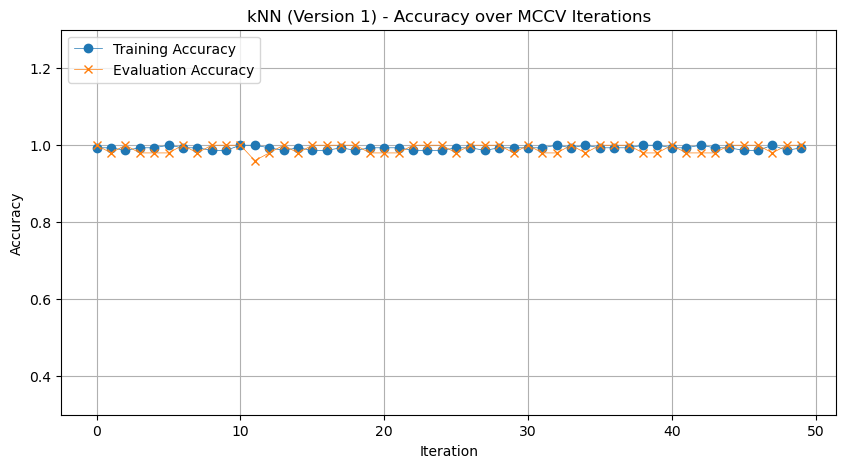

In [165]:
# Accuracy over MCCV iterations
plt.figure(figsize=(10, 5))
plt.plot(train_scores, label='Training Accuracy', marker='o', linewidth=0.5)
plt.plot(test_scores, label='Evaluation Accuracy', marker='x', linewidth=0.5)
plt.title("kNN (Version 1) - Accuracy over MCCV Iterations")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.legend(loc='upper left')
plt.ylim(0.3, 1.3)
plt.show()

### Plot the average confussion matrix

In [166]:
# Function that plots the average confussion matrix
def plot_confusion_matrix(cm, labels, title='kNN (Version 1) MCCV - Average Confusion Matrix', cmap='Blues'):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=labels,
                yticklabels=labels)

    plt.title(title, fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

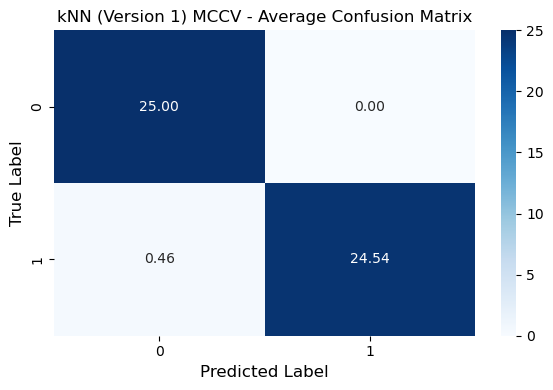

In [167]:
# Plot confusion matrix
plot_confusion_matrix(cm_avg, labels)

### End time

In [168]:
# End time
end_time = time.time()

### Elapsed time

In [169]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for kNN (Version 1): {elapsed_time:.2f} seconds")

Elapsed time for kNN (Version 1): 1.18 seconds
